In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

# Partie 1

In [2]:
def Rp_bis(Qint, omega0, C=10*1E-9):
    return Qint/(C*omega0)

def Q_int(Q,R,omega0, C=10*1E-9):
    Q_ext = R*C*omega0
    return 1/(1/Q - 1/Q_ext)

In [118]:
R = 47                                                  #Changer la résistance pour chaque plot
freq = pd.read_csv(f'Bode_{R}.csv')['Frequency [Hz]']
gain = pd.read_csv(f'Bode_{R}.csv')[' Amplitude [dB]']
phase = pd.read_csv(f'Bode_{R}.csv')[' Phase [deg]']

amp = 10**(gain/20)

C = 10e-9  # F
L = 100e-3
file = f'Bode_{R}.csv'

def model(f, f0, A, Q):
    return A / np.sqrt(1 + Q**2 * (f/f0 - f0/f)**2)

def Qint(Q, R, f0, C=C):
    omega0 = 2*np.pi*f0
    Q_ext = R * C * omega0
    return 1/ (1/Q_loaded - 1/Q_ext)

def Rp(Qint, f0, C=C):
    omega0 = 2*np.pi*f0
    return Qint / (C * omega0)

def pertes(Rp, R):
    return Rp/(R+Rp)

df = pd.read_csv(file)
freq = df['Frequency [Hz]'].to_numpy()
gain_db = df[' Amplitude [dB]'].to_numpy()  
amp = 10**(gain_db / 20.0)  

p0 = (np.mean(freq), np.max(amp), 50.0) 
bounds = ([0, 0, 1e-1], [np.max(freq)*2, 10.0, 1e4])  

popt, pcov = curve_fit(model, freq, amp, p0=p0, bounds=bounds, maxfev=20000)
f0_fit, A_fit, Q_fit = popt
perr = np.sqrt(np.diag(pcov))

omega0 = 2*np.pi*f0_fit
Q_loaded = abs(Q_fit)
Q_int = abs(Qint(Q_loaded, 47*10**3, f0=f0_fit))  
Rp_val = Rp(Q_int, f0_fit)


print(f"f0 = {f0_fit:.3f} Hz ± {perr[0]:.3f}")
print(f"A  = {A_fit:.5f} ± {perr[1]:.5f}")
print(f"Q = {Q_loaded:.3f} ± {perr[2]:.3f}")
print(f"omega0 = {omega0:.3f} rad/s")
print(f"omega0 théorique {1/np.sqrt(L*C)}")
print(f"Q_int = {Q_int:.3f}")
print(f"Rp (from Q_int) = {Rp_val/1e3:.2f} kΩ")
print(f"Loss {pertes(Rp_val/1e3, R)}")

f_fine = np.linspace(np.min(freq), np.max(freq), 2000)

f0 = 5136.417 Hz ± 10.665
A  = 7.43876 ± 72.42228
Q = 163.041 ± 1589.873
omega0 = 32273.060 rad/s
omega0 théorique 31622.776601683792
Q_int = 16.724
Rp (from Q_int) = 51.82 kΩ
Loss 0.5243930916447495


In [119]:
R = R*1E3
Q_th = R*Rp_val/(R+Rp_val)*C*omega0
print(Q_th)
Qext = R*C*omega0
print(1/Q_th - 1/Qext)

7.954171831209357
0.05979339124773961


<>:20: SyntaxWarning: invalid escape sequence '\O'
<>:20: SyntaxWarning: invalid escape sequence '\O'
C:\Users\jolet\AppData\Local\Temp\ipykernel_15640\1223772976.py:20: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Diagramme de Bode du filtre RCL pour $R = {R} k\Omega$")


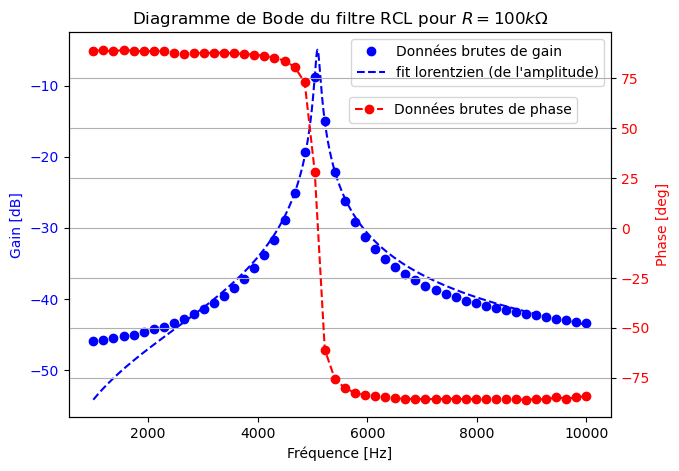

In [69]:
fig, ax1 = plt.subplots(figsize=(7, 5))


plt.plot(freq, gain, 'o', color ='b', label ='Données brutes de gain')
plt.plot(f_fine, 20*np.log10(model(f_fine, *popt)), color ='b', linestyle ='--', label="fit lorentzien (de l'amplitude)")
plt.legend()

ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='Données brutes de phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.legend(loc = 'best', bbox_to_anchor=(0.45, 0., 0.5, 0.85))


plt.title(f"Diagramme de Bode du filtre RCL pour $R = {R} k\Omega$")
plt.grid(which='both')
plt.show()


# Démarage des oscillations

In [70]:
R2 = 2E3
R1 = 2.2E3
G_dem = 1+R2/R1
print("Gain au démarrage des oscillations", 1 + R2/R1)

Gain au démarrage des oscillations 1.9090909090909092


In [72]:
1/1.91

0.5235602094240838

In [75]:
mean_Rp = np.mean(np.array([51.82,63.1, 60.12, 67.3]))

In [77]:
((100 + mean_Rp)/mean_Rp - 1)*2

3.3011471486341506

[ 10  30  50  70  90 111 132 152 172 192 213 233 253 273 293 314 334]


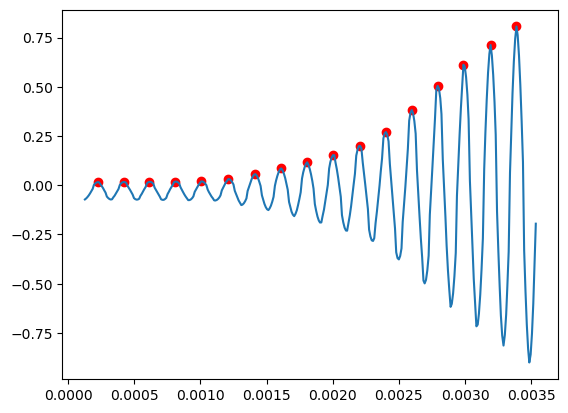

In [95]:
pd.read_csv('scopeData(23).csv')

time = pd.read_csv('scopeData(23).csv')['TIME ms']*1E-3
Vin = pd.read_csv('scopeData(23).csv')[' IN2']
time = time.to_numpy()
Vin = Vin.to_numpy()
time_cropped, Vin_cropped = np.flip(time[150:500]), Vin[150:500]

from scipy.signal import find_peaks

peaks = find_peaks(Vin_cropped, height=None)
plt.plot(time_cropped, Vin_cropped)
print(peaks[0])

x = time_cropped[peaks[0]]
y = Vin_cropped[peaks[0]]
plt.scatter(x, y, color ='r')

1167.9685775092153
13.537511715050522


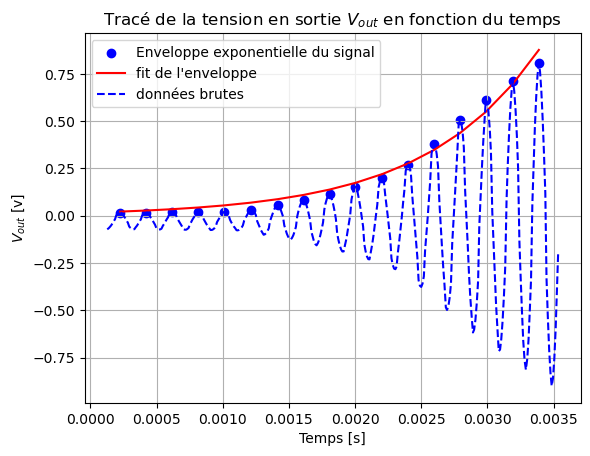

In [97]:
def model_bis(t,alpha,A):
    return A*np.exp(alpha*t)

popt, pcov = curve_fit(model_bis, x,y, p0 = [-800,1])
alpha_bis,A = popt
print(alpha_bis)

Q = 1/(np.sqrt(L*C)*2*alpha_bis)
print(Q)

#plt.plot(time_cropped, model(time_cropped, *p0))
plt.title('Tracé de la tension en sortie $V_{out}$ en fonction du temps')
plt.scatter(x, y, color ='b', label ='Enveloppe exponentielle du signal')
plt.plot(x,model_bis(x,*popt), color ='r', label ="fit de l'enveloppe")
plt.plot(time_cropped, Vin_cropped, color ='b', linestyle ='--', label ='données brutes')
plt.legend()
plt.xlabel("Temps [s]")
plt.ylabel("$V_{out}$ [v]")
plt.grid()
plt.show()

In [108]:
R = 47*1E3
R_p = mean_Rp*1E3

Q_th = R*R_p/(R+R_p)*C*1/(np.sqrt(L*C))
print(Q_th)

8.369726101167595
